In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("airbnb_datasheet_cleaned.csv")

## Data Overview

In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,revenue_estimate
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,4.889500e+04
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,7.143982,112.781327,1.981057e+04
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,32.952519,131.622289,5.900602e+04
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,1.000000,0.000000,0.000000e+00
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,1.000000,45.000000,4.293000e+03
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.000000,227.000000,2.251500e+04
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,327.000000,365.000000,3.649635e+06


## Top Revenue Boroughs

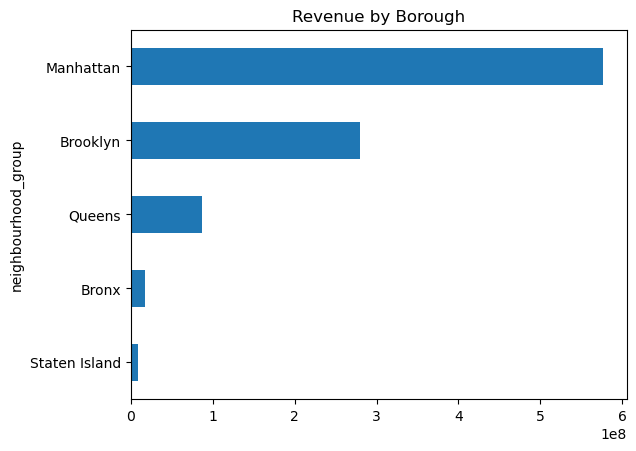

In [4]:
borough_rev = df.groupby(
    "neighbourhood_group"
)["revenue_estimate"].sum()

borough_rev.sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Borough")
plt.show()

## Revenue by Room Type

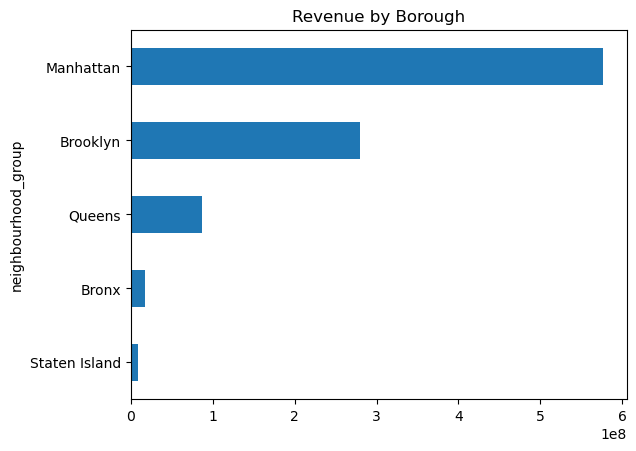

In [5]:
borough_rev = df.groupby(
    "neighbourhood_group"
)["revenue_estimate"].sum()

borough_rev.sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Borough")
plt.show()

## Correlation Analysis

In [6]:
corr = df[
[
"price",
"number_of_reviews",
"availability_365",
"revenue_estimate"
]
].corr()

print(corr)

                      price  number_of_reviews  availability_365  \
price              1.000000          -0.047954          0.081829   
number_of_reviews -0.047954           1.000000          0.172028   
availability_365   0.081829           0.172028          1.000000   
revenue_estimate   0.715071           0.014538          0.413550   

                   revenue_estimate  
price                      0.715071  
number_of_reviews          0.014538  
availability_365           0.413550  
revenue_estimate           1.000000  


## Top 10 Neighborhoods

In [7]:
top10 = df.groupby(
    "neighbourhood"
)["revenue_estimate"].sum()

top10 = top10.sort_values(
    ascending=False
).head(10)

print(top10)

neighbourhood
Midtown               79291730
Hell's Kitchen        60923956
Bedford-Stuyvesant    52901281
Williamsburg          52698139
Upper West Side       49121398
Upper East Side       43651672
Harlem                38924462
Chelsea               38007066
Financial District    34205597
East Village          31610484
Name: revenue_estimate, dtype: int64


## Top Hosts

In [8]:
hosts = df.groupby(
    "host_name"
)["revenue_estimate"].sum()

hosts.sort_values(
    ascending=False
).head(10)

host_name
Sonder (NYC)    24563716
Blueground      18021038
Jessica         11045293
Kara            10656021
David            7834953
Red Awning       7686699
Kevin            6921026
Henry            6800246
Alex             6793232
Michael          6690351
Name: revenue_estimate, dtype: int64